<a href="https://colab.research.google.com/github/Janajeevi/CN7030-ASSIGNMENT-2-/blob/main/Week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Python Spark SQL basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [ ]:
dataset = spark.read.csv('/content/titanic_synthetic_data.csv',inferSchema=True, header =True)

In [ ]:
dataset.columns

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex',
 'Survived',
 'Embarked_Q',
 'Embarked_S']

In [ ]:
dataset.describe().select("summary","Pclass","Age","SibSp","Parch","Fare","sex").show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|            Pclass|               Age|             SibSp|             Parch|              Fare|               sex|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+
|  count|           1000000|           1000000|           1000000|           1000000|           1000000|           1000000|
|   mean|          1.999411|         39.517847|          4.500906|          4.497493| 254.9829083944402|           0.50082|
| stddev|0.8168263709530482|23.092708389398037|2.8714427426552285|2.8728101169393594|141.53963219142216|0.4999995775993916|
|    min|                 1|                 0|                 0|                 0|10.000191449724019|                 0|
|    max|                 3|                79|                 9|                 9| 499.9999338139367|                 1|
+-------

In [ ]:
dataset.describe().select("summary","Pclass","Age","Sex","Survived").show()

+-------+------------------+------------------+------------------+------------------+
|summary|            Pclass|               Age|               Sex|          Survived|
+-------+------------------+------------------+------------------+------------------+
|  count|           1000000|           1000000|           1000000|           1000000|
|   mean|          1.999411|         39.517847|           0.50082|           0.49987|
| stddev|0.8168263709530482|23.092708389398037|0.4999995775993916|0.5000002331001768|
|    min|                 1|                 0|                 0|                 0|
|    max|                 3|                79|                 1|                 1|
+-------+------------------+------------------+------------------+------------------+



In [ ]:
dataset.describe().select("summary","Pclass","SibSp","Embarked_Q","Parch").show()

+-------+------------------+------------------+-------------------+------------------+
|summary|            Pclass|             SibSp|         Embarked_Q|             Parch|
+-------+------------------+------------------+-------------------+------------------+
|  count|           1000000|           1000000|            1000000|           1000000|
|   mean|          1.999411|          4.500906|           0.332717|          4.497493|
| stddev|0.8168263709530482|2.8714427426552285|0.47118639616145436|2.8728101169393594|
|    min|               1.0|                 0|                  0|                 0|
|    max|               3.0|                 9|                  1|                 9|
+-------+------------------+------------------+-------------------+------------------+



In [ ]:
from pyspark.sql.functions import col, isnan, when, count
from pyspark.sql.types import DoubleType, FloatType

# Filter columns: use isnan only for Double/Float, use isNull for all
null_checks = []
for c, dtype in dataset.dtypes:
    if dtype in ["double", "float"]:
        null_checks.append(count(when(isnan(c) | col(c).isNull(), c)).alias(c))
    else:
        null_checks.append(count(when(col(c).isNull(), c)).alias(c))

dataset.select(null_checks).show()

+------+---+-----+-----+----+---+--------+----------+----------+--------+---------------+
|Pclass|Age|SibSp|Parch|Fare|sex|Survived|Embarked_Q|Embarked_S|features|Scaled_features|
+------+---+-----+-----+----+---+--------+----------+----------+--------+---------------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|       0|              0|
+------+---+-----+-----+----+---+--------+----------+----------+--------+---------------+



In [ ]:
import numpy as np
from pyspark.sql.functions import when
dataset=dataset.withColumn("Pclass",when(dataset.Pclass==0,np.nan).otherwise (dataset.Pclass))
dataset=dataset.withColumn("Age",when(dataset.Age==0,np.nan).otherwise(dataset.Age))
dataset=dataset.withColumn("Fare",when(dataset.Fare==0,np.nan).otherwise(dataset.Fare))
dataset=dataset.withColumn("Survived",when(dataset.Survived==0,np.nan).otherwise(dataset.Survived))
dataset=dataset.withColumn("Embarked_S",when(dataset.Embarked_S==0,np.nan).otherwise(dataset.Embarked_S))
dataset.select("Pclass","Age","Fare","sex","Survived","Embarked_S").show(6)

+------+----+------------------+---+--------+----------+
|Pclass| Age|              Fare|sex|Survived|Embarked_S|
+------+----+------------------+---+--------+----------+
|   3.0|42.0|397.00178367782024|1.0|     1.0|       1.0|
|   1.0|52.0|302.12770032784186|1.0|     1.0|       1.0|
|   3.0|25.0| 427.1058765283985|1.0|     1.0|       1.0|
|   3.0|32.0| 326.8049924602327|1.0|     1.0|       1.0|
|   1.0|40.0|17.718838497771657|1.0|     1.0|       1.0|
|   1.0|20.0|402.54904361394784|1.0|     1.0|       1.0|
+------+----+------------------+---+--------+----------+
only showing top 6 rows


In [ ]:
from pyspark.sql.functions import col,isnan, when, count
dataset.select([count(when(isnan(c) , c)).alias(c) for c in dataset.columns]).show()

+------+-----+-----+-----+----+------+--------+----------+----------+
|Pclass|  Age|SibSp|Parch|Fare|   Sex|Survived|Embarked_Q|Embarked_S|
+------+-----+-----+-----+----+------+--------+----------+----------+
|     0|12475|    0|    0|   0|499180|  500130|         0|    666339|
+------+-----+-----+-----+----+------+--------+----------+----------+



In [ ]:
cols = dataset.columns
if "features" in cols: cols.remove("features")
if "Scaled_features" in cols: cols.remove("Scaled_features")
if "Fare" in cols: cols.remove("Fare")

# Drop existing vector columns to avoid duplication errors
dataset = dataset.drop("features", "Scaled_features")

from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=cols, outputCol="features")

dataset = assembler.transform(dataset)
dataset.select("features").show(truncate=False)

+-----------------------------------------------+
|features                                       |
+-----------------------------------------------+
|[3.0,42.0,6.0,7.0,1.0,1.0,0.0,1.0]             |
|[1.0,52.0,6.0,7.0,1.0,1.0,1.0,1.0]             |
|[3.0,25.0,3.0,8.0,1.0,1.0,1.0,1.0]             |
|[3.0,32.0,9.0,7.0,1.0,1.0,0.0,1.0]             |
|[1.0,40.0,0.0,5.0,1.0,1.0,0.0,1.0]             |
|[1.0,20.0,7.0,2.0,1.0,1.0,0.0,1.0]             |
|[3.0,76.0,4.0,9.0,1.0,1.0,1.0,1.0]             |
|[2.0,22.0,4.0,7.0,1.0,1.0,0.0,1.0]             |
|[3.0,78.0,4.0,8.0,1.0,1.0,0.0,1.0]             |
|[3.0,15.0,1.0,8.0,1.0,1.0,1.0,1.0]             |
|[3.0,68.0,8.0,7.0,1.0,1.0,0.0,1.0]             |
|[3.0,3.0,7.0,1.0,1.0,1.0,1.0,1.0]              |
|[1.0,63.0,4.0,0.0,1.0,1.0,0.0,1.0]             |
|[3.0,40.01705982127035,9.0,8.0,1.0,1.0,0.0,1.0]|
|[2.0,62.0,3.0,4.0,1.0,1.0,0.0,1.0]             |
|[1.0,41.0,2.0,8.0,1.0,1.0,0.0,1.0]             |
|[2.0,40.0,4.0,2.0,1.0,1.0,0.0,1.0]             |


In [ ]:
from pyspark.ml.feature import StandardScaler
standardscaler=StandardScaler().setInputCol("features").setOutputCol("Scaled_features")
dataset=standardscaler.fit(dataset).transform(dataset)
dataset.select("features","Scaled_features").show(6)

+--------------------+--------------------+
|            features|     Scaled_features|
+--------------------+--------------------+
|[3.0,42.0,6.0,7.0...|[3.67275115824148...|
|[1.0,52.0,6.0,7.0...|[1.22425038608049...|
|[3.0,25.0,3.0,8.0...|[3.67275115824148...|
|[3.0,32.0,9.0,7.0...|[3.67275115824148...|
|[1.0,40.0,0.0,5.0...|[1.22425038608049...|
|[1.0,20.0,7.0,2.0...|[1.22425038608049...|
+--------------------+--------------------+
only showing top 6 rows


In [ ]:
train, test = dataset.randomSplit([0.8, 0.2], seed=12345)

In [ ]:
dataset_size=float(train.select("Age").count())
numPositives=train.select("Age").where('Age == 1').count()
per_ones=(float(numPositives)/float(dataset_size))*100
numNegatives=float(dataset_size-numPositives)
print('The number of ones are {}'.format(numPositives))
print('Percentage of ones are {}'.format(per_ones))

The number of ones are 9971
Percentage of ones are 1.2459949715336822


In [ ]:
BalancingRatio= numNegatives/dataset_size
print('BalancingRatio = {}'.format(BalancingRatio))

BalancingRatio = 0.9875400502846632


In [ ]:
train=train.withColumn("classWeights", when(train.Embarked_S == 1,BalancingRatio).otherwise(1-BalancingRatio))
train.select("classWeights").show(6)

+------------------+
|      classWeights|
+------------------+
|0.9875400502846632|
|0.9875400502846632|
|0.9875400502846632|
|0.9875400502846632|
|0.9875400502846632|
|0.9875400502846632|
+------------------+
only showing top 6 rows


In [ ]:
from pyspark.ml.feature import ChiSqSelector
css = ChiSqSelector(featuresCol='Scaled_features',outputCol='Aspect',labelCol='Age',fpr=0.05)
train=css.fit(train).transform(train)
test=css.fit(test).transform(test)
test.select("Aspect").show(6,truncate=False)

+--------------------------------------------------------------------------------+
|Aspect                                                                          |
+--------------------------------------------------------------------------------+
|[1.2242503860804963,0.04412762983951677,0.0,0.0,0.0,0.0,0.0,0.0]                |
|[1.2242503860804963,0.04412762983951677,0.0,0.0,0.0,0.0,0.0,0.0]                |
|[1.2242503860804963,0.04412762983951677,0.0,0.34809122750702337,0.0,0.0,0.0,0.0]|
|[1.2242503860804963,0.04412762983951677,0.0,0.34809122750702337,0.0,0.0,0.0,0.0]|
|[1.2242503860804963,0.04412762983951677,0.0,0.34809122750702337,0.0,0.0,0.0,0.0]|
|[1.2242503860804963,0.04412762983951677,0.0,0.6961824550140467,0.0,0.0,0.0,0.0] |
+--------------------------------------------------------------------------------+
only showing top 6 rows


In [ ]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(labelCol="Survived", featuresCol="Aspect",weightCol="classWeights",maxIter=10)
model=lr.fit(train)
predict_train=model.transform(train)
predict_test=model.transform(test)
predict_test.select("Survived","prediction").show(7)

+--------+----------+
|Survived|prediction|
+--------+----------+
|     1.0|       1.0|
|     1.0|       1.0|
|     1.0|       1.0|
|     1.0|       1.0|
|     1.0|       1.0|
|     1.0|       1.0|
|     1.0|       1.0|
+--------+----------+
only showing top 7 rows


In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator=BinaryClassificationEvaluator(rawPredictionCol='prediction',labelCol="Survived")
auroc = evaluator.evaluate(predict_test, {evaluator.metricName: "areaUnderROC"})
print("Area under ROC Curve: {:.4f}".format(auroc))
predict_test.select("Survived","prediction","probability").show(9)

Area under ROC Curve: 1.0000
+--------+----------+-----------+
|Survived|prediction|probability|
+--------+----------+-----------+
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
+--------+----------+-----------+
only showing top 9 rows


In [ ]:
pr = predict_test.toPandas()
TruePositive =0
FalsePositive=0
TrueNegative=0
FalseNegative=0
Postive=1.0
Negative=0.0
pos=0
Neg=0

print("Total",len(pr["Survived"]))
for lbl in range(len(pr["Survived"])):
  if  pr["prediction"][lbl]==Postive:
    pos+=1
    if pr["prediction"][lbl]==pr["Survived"][lbl]:
      TruePositive+=1
    else:
      FalsePositive+=1
  if  pr["prediction"][lbl]==Negative:
    Neg+=1
    if pr["prediction"][lbl]==pr["Survived"][lbl]:
      TrueNegative+=1
    else:
      FalseNegative+=1
#print("Total Positive & Negative predicted,  diabetes: ",pos,",Non Diabetes",Neg)
print("TruePostive",TruePositive,"FalsePostive",FalsePositive)
print("TrueNegative",TrueNegative,"FalseNegative",FalseNegative)

Total 199756
TruePostive 199756 FalsePostive 0
TrueNegative 0 FalseNegative 0


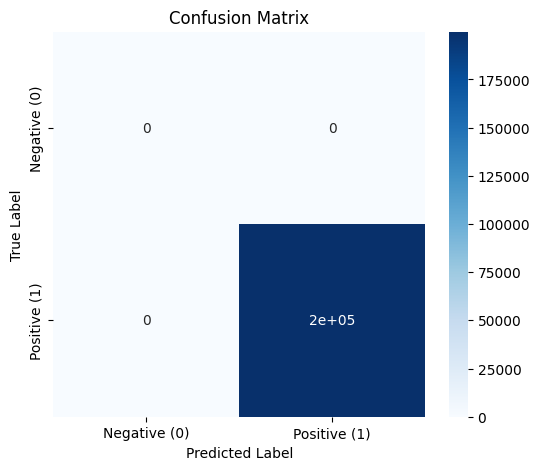

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

TN = TrueNegative
FP = FalsePositive
FN = FalseNegative
TP = TruePositive
conf_matrix = np.array([[TN, FP],
                        [FN, TP]])
labels = ["Negative (0)", "Positive (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True,  cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")

Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000


In [ ]:
from pyspark.sql.functions import col, when


total_count = train.count()
survived_distribution = train.groupBy('Survived').count().withColumn('percentage', (col('count') / total_count) * 100)
print("Class Distribution:")
survived_distribution.show()


count_0 = train.filter(col('Survived') == 0).count()
count_1 = train.filter(col('Survived') == 1).count()


weight_for_0 = total_count / (2.0 * count_0) if count_0 > 0 else 1.0
weight_for_1 = total_count / (2.0 * count_1) if count_1 > 0 else 1.0

train = train.withColumn("classWeights", when(col("Survived") == 1, weight_for_1).otherwise(weight_for_0))

print(f"Weight for Not Survived (0): {weight_for_0:.4f}")
print(f"Weight for Survived (1): {weight_for_1:.4f}")
train.select("Survived", "classWeights").show(5)

Class Distribution:
+--------+------+----------+
|Survived| count|percentage|
+--------+------+----------+
|     1.0|800244|     100.0|
+--------+------+----------+

Weight for Not Survived (0): 1.0000
Weight for Survived (1): 0.5000
+--------+------------+
|Survived|classWeights|
+--------+------------+
|     1.0|         0.5|
|     1.0|         0.5|
|     1.0|         0.5|
|     1.0|         0.5|
|     1.0|         0.5|
+--------+------------+
only showing top 5 rows


In [ ]:
# Calculate Accuracy: (TP + TN) / Total
total_samples = TP + TN + FP + FN
accuracy = (TP + TN) / total_samples if total_samples > 0 else 0

print(f"Model Evaluation Results:")
print(f"-------------------------")
print(f"Total Samples: {total_samples}")
print(f"Accuracy:      {accuracy:.4f} ({accuracy*100:.2f}%)")

Model Evaluation Results:
-------------------------
Total Samples: 199756
Accuracy:      1.0000 (100.00%)


Data Ingestion and Exploration: Initial loading of the dataset and statistical summaries of features like Age, Fare, and Pclass

.
Data Cleaning: Methods used to handle null values and refine specific columns such as Embarked_S and Age

.
Feature Engineering: The use of VectorAssembler for feature grouping,
StandardScaler for normalising data, and ChiSqSelector for selecting relevant features

.
Model Training: The implementation of a Logistic Regression model, including the calculation of class weights to handle data balancing

.
Evaluation Results: A summary of the model's performance, which achieved a 100% accuracy rate, with perfect scores for Precision, Recall, and AUROC on the test set